<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/fabiobento/dnn-course-2026-1/blob/main/C1_M1_Lab_2_activation_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

# Modelagem de Padrões Não Lineares com Funções de Ativação



No último laboratório, seu modelo linear simples teve um bom desempenho nos dados apenas de bicicletas, mas enfrentou dificuldades quando os carros foram adicionados. O motivo era simples: seu modelo só conseguia aprender **linhas retas**, mas os novos dados seguiam uma **curva**. Como você viu nas aulas teóricas, simplesmente adicionar mais neurônios lineares não é a solução. A saída do modelo continuaria sendo uma linha reta.

É aqui que entram as **funções de ativação não lineares**. Elas são a chave para desbloquear a capacidade do seu modelo de aprender os padrões complexos e curvos encontrados nos dados do mundo real. Neste laboratório, você usará a função de ativação mais popular e poderosa, a **ReLU (Rectified Linear Unit)**, para construir um modelo mais sofisticado. Ao adicionar uma ativação ReLU, seu modelo pode criar múltiplas "dobras" que conseguem aproximar a complexa curva do tempo de entrega.

Neste laboratório, você irá:

* Preparar os dados combinados de entrega por bicicleta e carro, desta vez aplicando uma técnica chamada **normalização** para ajudar seu modelo a treinar de forma mais eficaz.
* Construir uma rede neural *não linear* usando a função de ativação **ReLU**.
* Treinar seu novo modelo para aprender a relação complexa e curva nos dados.
* Prever os tempos de entrega usando seu novo modelo e ver se ele finalmente consegue ter sucesso onde o linear falhou.

## Importação de bibliotecas

In [1]:
import os
# Verificar se o arquivo existe localmente antes de baixar
if not os.path.exists('helper_utils_1.py'):
    !wget -q https://raw.githubusercontent.com/fabiobento/dnn-course-2026-1/main/helper_utils_1.py -O helper_utils_1.py

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils_1

## Preparando os Dados Não Lineares

Comece carregando o mesmo conjunto de dados que causou problemas ao final do último laboratório. Estes são os dados combinados das entregas feitas tanto por bicicleta quanto por carro.

In [3]:
# Conjunto de dados combinado: bicicletas para distâncias curtas, carros para as mais longas
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Tempos de entrega correspondentes em minutos
times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

* Como você verá ao executar o código abaixo, o gráfico dos dados segue um padrão não linear.

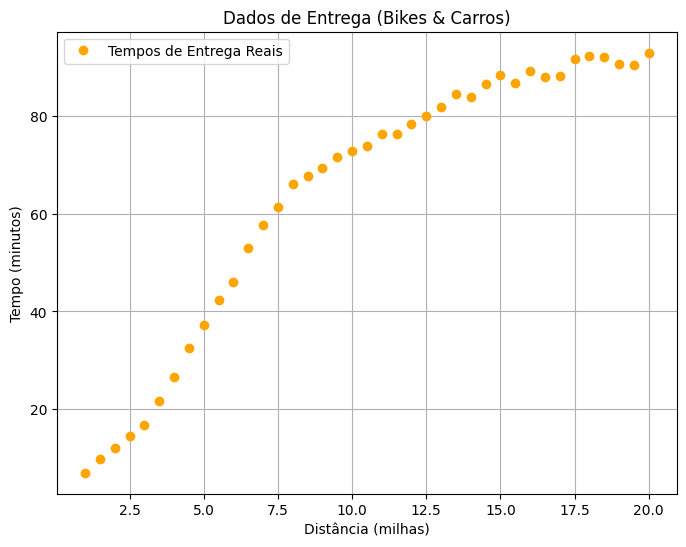

In [4]:
helper_utils_1.plot_data(distances, times)

### Uma Nova Etapa: Normalizando os Dados

Antes de construir seu modelo, você aplicará uma etapa rápida de preparação de dados chamada **normalização**. Esta é uma técnica padrão que torna o processo de treinamento mais estável e eficaz ao ajustar a escala dos dados. Esse ajuste ajuda a evitar que grandes valores de distância dominem o processo de aprendizagem e mantém os gradientes estáveis durante o treinamento. Você explorará este tópico com mais detalhes em uma aula posterior.

* Você calculará a média (*mean*) e o desvio padrão (*standard deviation*) para os tensores `distances` e `times`.
* Em seguida, você aplicará a padronização a cada tensor usando sua respectiva média e desvio padrão, o que criará novos tensores normalizados chamados `distances_norm` and `times_norm`.
* Esta técnica específica é chamada de **padronização** (ou [normalização z-score](https://en-wikipedia-org.translate.goog/wiki/Standard_score?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc)), que converte os dados originais de `1,0 a 20,0 milhas` e aproximadamente `7 a 93 minutos` para uma nova escala normalizada.

In [9]:
# Calcule a média e o desvio padrão para o tensor 'distances' (distâncias)
distances_mean = distances.mean()
distances_std = distances.std()

# Calcule a média e o desvio padrão para o tensor 'times' (tempos)
times_mean = times.mean()
times_std = times.std()

# Aplique a padronização (standardization) às distâncias.
distances_norm = (distances - distances_mean) / distances_std

# Aplique a padronização (standardization) aos tempos.
times_norm = (times - times_mean) / times_std

* Você notará que os eixos agora mostram os dados em uma nova escala normalizada, com a distância variando de aproximadamente `-1,7 a 1,7` e o tempo de `-2,0 a 1,0`.
* Apesar dessa mudança na escala, o padrão curvo subjacente dos dados permanece exatamente o mesmo.

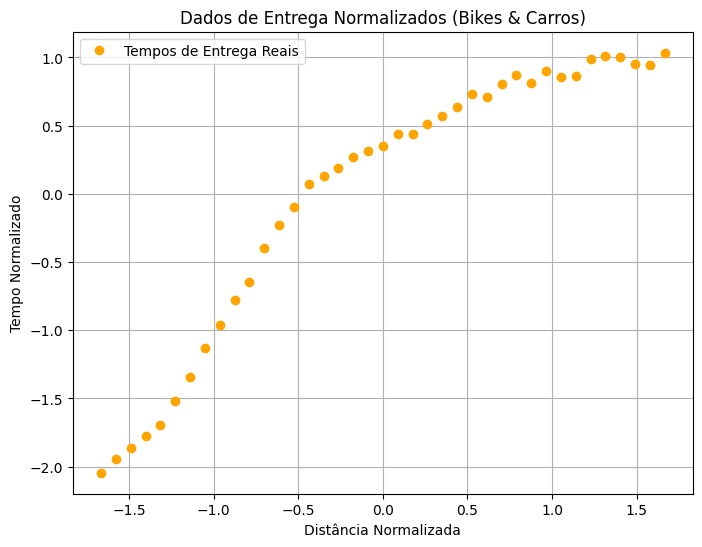

In [10]:
helper_utils_1.plot_data(distances_norm, times_norm, normalize=True)

## Construindo o Modelo Não Linear

Com seus dados normalizados prontos, agora você pode construir um modelo capaz de aprender seu padrão curvo. Você definirá a arquitetura do modelo, que agora inclui uma função de ativação `ReLU`. Essa estrutura é o que dá ao seu modelo a capacidade de aprender relações não lineares.

* `nn.Linear(1, 3)`: Esta é a sua **primeira camada oculta** (*hidden layer*). Ela consiste em três neurônios, cada um recebendo uma característica de entrada (a distância normalizada). Esta camada transforma o valor de entrada único em três valores distintos.
* `nn.ReLU()` aplica a função de ativação ReLU à saída de cada um dos três neurônios da camada oculta. Este é o passo não linear crucial que permite ao seu modelo criar "dobras" e aprender curvas em vez de apenas linhas retas.
* `nn.Linear(3, 1)`: Esta é a sua **camada de saída** (*output layer*). Ela recebe os três valores ativados do passo anterior como entrada e os combina para produzir uma única saída final, que é o seu tempo de entrega (normalizado) previsto.

Isso cria uma rede neural com 1 camada oculta contendo 3 neurônios.

In [11]:
# Esta linha garante que seus resultados sejam reproduzíveis e consistentes todas as vezes.
torch.manual_seed(27)

model = nn.Sequential(
    nn.Linear(1, 3), # Camada de entrada (1) para camada oculta (3 neurônios)
    nn.ReLU(),       # Função de ativação não linear
    nn.Linear(3, 1)  # Camada oculta (3) para camada de saída (1)
)

## Treinamento

* Defina a função de perda (*loss function*) e o otimizador para o treinamento.

In [8]:
# Definir a função de perda (loss) e o otimizador
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

Com seu modelo e ferramentas de treinamento prontos, você pode iniciar o processo de treinamento.

* Você executará o loop de treinamento por `3000` épocas (mais do que no Laboratório 1, pois o padrão não linear é mais complexo e exige mais treinamento). Isso fornecerá repetidamente os dados *normalizados* ao seu modelo, medirá o erro e ajustará os parâmetros do modelo para melhorar suas previsões.
* A segunda metade do código inclui um gráfico em tempo real (*live plot*), permitindo que você observe enquanto a linha de previsão do seu modelo se adapta para se ajustar aos dados curvos. O gráfico ajuda a ver como o modelo aprende a curva gradualmente, começando com um ajuste ruim e melhorando com o tempo.

**NOTA IMPORTANTE**: Como o gráfico é atualizado em tempo real durante o treinamento, você pode notar um efeito de oscilação (*flickering*). Este é o comportamento esperado da visualização ao vivo e não um problema com sua tela.

In [ ]:
# Loop de treinamento
for epoch in range(3000):
    # Redefina os gradientes do otimizador (zerar o erro acumulado)
    optimizer.zero_grad()
    
    # Realize as previsões (passagem para frente / forward pass)
    outputs = model(distances_norm)
    
    # Calcule a perda (erro entre a previsão e o real)
    loss = loss_function(outputs, times_norm)
    
    # Calcule os ajustes necessários (retropropagação / backward pass)
    loss.backward()
    
    # Atualize os parâmetros (pesos e viés) do modelo
    optimizer.step()

    # Crie um gráfico em tempo real a cada 50 épocas
    if (epoch + 1) % 50 == 0:
        helper_utils_1.plot_training_progress(
            epoch=epoch,
            loss=loss,
            model=model,
            distances_norm=distances_norm,
            times_norm=times_norm
        )

print("\nTreinamento Concluído.")
print(f"\nPerda Final: {loss.item()}")

## Checking the Final Fit 

Now that training is complete, you will visualize the result.

* You will plot your model's final predicted curve against the original data points.
* This lets you visually inspect how well your non-linear model learned to fit the complex data pattern.

In [ ]:
helper_utils.plot_final_fit(model, distances, times, distances_norm, times_std, times_mean)

<br>

Congratulations! You have successfully trained your first **non-linear** neural network in PyTorch!

Where the simple linear model from the last lab failed, your new model with a `ReLU` activation function succeeded. As you can see from the plot, your model learned to capture the complex, curved relationship in the combined bike and car delivery data.

## Making a Prediction

With your fully trained non-linear model, you can now use it to make a prediction for a new delivery. The process is slightly different now because your model was trained on *normalized* data.

* First, you will take the new input distance and **normalize** it using the same mean and standard deviation from your training data. This step is CRITICAL: your model has no idea about the original scales (miles and minutes). It only understands the normalized scale it was trained on.
* After the model provides its prediction, you must **de-normalize** the output. This converts the prediction from its normalized scale back into an understandable value in minutes.
* Finally, the code uses this actual predicted time to run the decision logic. For this prediction, assume your company now promises deliveries within 45 minutes (instead of 30 minutes from Lab 1) and wants to know which vehicle to use.

In [ ]:
distance_to_predict = 5.1

In [ ]:
# Use the torch.no_grad() context manager for efficient prediction
with torch.no_grad():
    # Normalize the input distance
    distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    new_distance_norm = (distance_tensor - distances_mean) / distances_std
    
    # Get the normalized prediction from the model
    predicted_time_norm = model(new_distance_norm)
    
    # De-normalize the output to get the actual time in minutes
    predicted_time_actual = (predicted_time_norm * times_std) + times_mean
    
    # --- Decision Making Logic ---
    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time_actual.item():.1f} minutes")
    
    # First, check if the delivery is possible within the 45-minute timeframe
    if predicted_time_actual.item() > 45:
        print("\nDecision: Do NOT promise the delivery in under 45 minutes.")
    else:
        # If it is possible, then determine the vehicle based on the distance
        if distance_to_predict <= 3:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (<= 3 miles), use a bike.")
        else:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (> 3 miles), use a car.")

## Conclusion

You have now built and trained both a simple linear model and a more powerful non-linear model in PyTorch. In this lab, you saw firsthand how adding a non-linear activation function like **ReLU** gave your model the ability to succeed where the linear model had failed.

You have moved beyond fitting straight lines and can now capture the complex, curved patterns that are common in real-world data. You also learned a practical data preparation technique, normalization, that helps make the training process more stable and effective.

With these fundamental skills of building architectures, preparing data, and training models, you are well prepared for the next step. In the upcoming module, you will build on this foundation to tackle new kinds of problems, like classification, and dive even deeper into the mechanics of how neural networks learn.